# 15 -- Dense Retrieval Comparison
## LLM Lie Detector | ICML 2027 Research Track

This notebook compares keyword-based retrieval (Wikipedia API) against
dense retrieval (sentence-transformers + FAISS) on Experiment 1 conditions.

### Research Question
Does the retrieval quality cliff identified in Experiment 1 persist when
using semantic dense retrieval instead of keyword matching? If yes, the
finding generalizes beyond naive retrieval. If no, the finding is specific
to keyword retrieval quality.

### Method
Replicate Experiment 1 (perfect / partial / weak / irrelevant) using
sentence-transformers to encode queries and retrieve semantically similar
passages from a pre-built Wikipedia passage index.

### Why This Matters
A reviewer will ask: "Is this a retrieval method problem or a fundamental
limitation of RAG-augmented detection?" This experiment answers that directly.

In [1]:
import os, json, random, re
os.environ["PYTHONUTF8"] = "1"

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wikipedia
import wikipediaapi
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from huggingface_hub import login
from dotenv import load_dotenv

load_dotenv('../.env')
login(token=os.getenv("HF_TOKEN"))

# ── Load model ─────────────────────────────────────────────
model_id   = "meta-llama/Llama-3.2-3B-Instruct"
adapter_id = "tamimmirza/llama-3.2-3b-hallucination-detector"

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id, dtype=torch.bfloat16, device_map="auto"
)
model = PeftModel.from_pretrained(base_model, adapter_id)
model.eval()

# ── Load fixed sample ──────────────────────────────────────
fixed_sample   = pd.read_csv('../data/fixed_ablation_sample.csv')
baseline_labels = fixed_sample['label'].tolist()

# ── Core functions ─────────────────────────────────────────
def predict(question, answer, context=None):
    if context:
        prompt = (
            f"Context: {context}\n\n"
            f"Question: {question}\n"
            f"Answer: {answer}\n"
            f"Based on the context, is the answer truthful or hallucinated?\n"
            f"Verdict:"
        )
    else:
        prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output = model.generate(
            **inputs, max_new_tokens=10, temperature=0.1,
            do_sample=True, pad_token_id=tokenizer.eos_token_id
        )
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    return 1 if "HALLUCINATED" in response else 0

def evaluate(preds, labels):
    return {
        "f1":        round(f1_score(labels, preds, average='weighted'), 4),
        "precision": round(precision_score(labels, preds, average='weighted', zero_division=0), 4),
        "recall":    round(recall_score(labels, preds, average='weighted', zero_division=0), 4),
        "accuracy":  round(accuracy_score(labels, preds), 4),
    }

print(f"Model ready. VRAM: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"Fixed sample: {len(fixed_sample)} samples")
print(f"GPU: {torch.cuda.get_device_name(0)}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

W0525 23:23:47.465000 27788 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Model ready. VRAM: 6.4 GB
Fixed sample: 150 samples
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [2]:
# Install if needed -- run once
# !pip install sentence-transformers faiss-cpu --quiet

from sentence_transformers import SentenceTransformer
import faiss

# Load sentence transformer -- small and fast
print("Loading sentence transformer...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
print("Embedder ready.")

# Build a passage corpus from Wikipedia
# We collect passages on topics covered by TruthfulQA/HaluEval
# This is our retrieval knowledge base

wiki_api = wikipediaapi.Wikipedia(
    language='en',
    user_agent='LLMDetector/1.0 (tamim.mirza@rwth-aachen.de)'
)

CORPUS_TOPICS = [
    # Science
    "Photosynthesis", "Evolution", "Quantum mechanics", "DNA",
    "Black hole", "Relativity", "Vaccination", "Climate change",
    # History
    "World War II", "French Revolution", "Roman Empire",
    "American Civil War", "Byzantine Empire", "Cold War",
    # Geography
    "Amazon rainforest", "Sahara Desert", "Mount Everest",
    "Great Wall of China", "Eiffel Tower", "Nile River",
    # Culture / misc
    "Fortune cookie", "Ninja", "Vikings", "Magna Carta",
    "Olympic Games", "Nobel Prize", "United Nations",
    "Human body", "Solar system", "Internet",
]

print(f"Building corpus from {len(CORPUS_TOPICS)} Wikipedia topics...")
corpus_passages = []
corpus_titles   = []

for topic in CORPUS_TOPICS:
    page = wiki_api.page(topic)
    if page.exists():
        # Split summary into ~200 char chunks
        summary = page.summary
        chunks = [summary[i:i+200] for i in range(0, len(summary), 200)]
        for chunk in chunks[:3]:  # max 3 chunks per topic
            if len(chunk) > 50:
                corpus_passages.append(chunk)
                corpus_titles.append(topic)

print(f"Corpus built: {len(corpus_passages)} passages")

# Encode all passages
print("Encoding corpus passages...")
corpus_embeddings = embedder.encode(
    corpus_passages, show_progress_bar=True,
    convert_to_numpy=True
)

# Build FAISS index
dim = corpus_embeddings.shape[1]
index = faiss.IndexFlatL2(dim)
index.add(corpus_embeddings.astype(np.float32))

print(f"FAISS index built: {index.ntotal} vectors, dim={dim}")

Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Tamim\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedder ready.
Building corpus from 30 Wikipedia topics...
Corpus built: 87 passages
Encoding corpus passages...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

FAISS index built: 87 vectors, dim=384


In [3]:
def dense_retrieve(question: str, k: int = 1, 
                   min_score: float = None) -> list:
    """
    Retrieve top-k passages using dense semantic search.
    Returns list of (passage, title, distance) tuples.
    min_score: if set, filters out passages with distance above threshold.
    """
    query_embedding = embedder.encode([question], convert_to_numpy=True)
    distances, indices = index.search(
        query_embedding.astype(np.float32), k
    )
    
    results = []
    for dist, idx in zip(distances[0], indices[0]):
        if idx < len(corpus_passages):
            if min_score is None or dist < min_score:
                results.append((
                    corpus_passages[idx],
                    corpus_titles[idx],
                    float(dist)
                ))
    return results


def get_dense_perfect(question: str) -> str:
    """
    Dense perfect retrieval -- top-1 most semantically similar passage.
    Equivalent to best-case dense RAG.
    """
    results = dense_retrieve(question, k=1)
    if results:
        return results[0][0]
    return ""


def get_dense_partial(question: str) -> str:
    """
    Dense partial retrieval -- top-1 passage truncated to 100 chars.
    Simulates incomplete semantic match.
    """
    results = dense_retrieve(question, k=1)
    if results:
        return results[0][0][:100]
    return ""


def get_dense_weak(question: str) -> str:
    """
    Dense weak retrieval -- 3rd most similar passage.
    Simulates retrieving a related but off-target result.
    """
    results = dense_retrieve(question, k=3)
    if len(results) >= 3:
        return results[2][0]
    elif results:
        return results[-1][0]
    return ""


def get_dense_irrelevant(question: str) -> str:
    """
    Dense irrelevant retrieval -- least similar passage in corpus.
    Simulates complete retrieval failure.
    """
    query_embedding = embedder.encode([question], convert_to_numpy=True)
    distances, indices = index.search(
        query_embedding.astype(np.float32), len(corpus_passages)
    )
    # Take the last result -- most distant
    last_idx = indices[0][-1]
    if last_idx < len(corpus_passages):
        return corpus_passages[last_idx]
    return corpus_passages[-1]


# Test all four conditions
print("Testing dense retrieval conditions...")
test_q = "Where did fortune cookies originate?"

print(f"\nQ: {test_q}")
print(f"\n[DENSE PERFECT]")
print(get_dense_perfect(test_q)[:150])
print(f"\n[DENSE PARTIAL]")
print(get_dense_partial(test_q)[:150])
print(f"\n[DENSE WEAK]")
print(get_dense_weak(test_q)[:150])
print(f"\n[DENSE IRRELEVANT]")
print(get_dense_irrelevant(test_q)[:150])

Testing dense retrieval conditions...

Q: Where did fortune cookies originate?

[DENSE PERFECT]
s, Canada, Australia, and other countries, but they are not Chinese in origin. The exact origin of fortune cookies is unclear, though various immigran

[DENSE PARTIAL]
s, Canada, Australia, and other countries, but they are not Chinese in origin. The exact origin of f

[DENSE WEAK]
 may also include a Chinese phrase with translation or a list of lucky numbers used by some as lottery numbers. Fortune cookies are often served as a 

[DENSE IRRELEVANT]
Photosynthesis ( FOH-tə-SINTH-ə-sis) is a system of biological processes by which photopigment-bearing autotrophic organisms, such as most plants, alg


In [4]:
print("Running Dense Retrieval Experiment (Exp 1 replication)...")
print("4 conditions x 150 samples\n")

dense_conditions = {
    'no_retrieval':   lambda q: None,
    'dense_perfect':  lambda q: get_dense_perfect(q) or None,
    'dense_partial':  lambda q: get_dense_partial(q) or None,
    'dense_weak':     lambda q: get_dense_weak(q) or None,
    'dense_irrelevant': lambda q: get_dense_irrelevant(q),
}

dense_results = {}

for cname, fn in dense_conditions.items():
    print(f"Running: {cname.upper()}...")
    preds = []

    for i, row in fixed_sample.iterrows():
        ctx = fn(row['question'])
        preds.append(predict(row['question'], row['answer'], ctx))

    metrics = evaluate(preds, baseline_labels)
    dense_results[cname] = metrics
    print(f"  F1: {metrics['f1']} | Accuracy: {metrics['accuracy']}")

print("\n" + "=" * 65)
print("DENSE RETRIEVAL RESULTS vs KEYWORD RETRIEVAL (Exp 1)")
print("=" * 65)
print(f"{'Condition':<22} {'Dense F1':>10} {'Keyword F1':>12} {'Delta':>8}")
print("-" * 65)

# Load keyword exp1 stats for comparison
with open('../outputs/statistical_results.json') as f:
    stats_all = json.load(f)

keyword_map = {
    'no_retrieval':    'no_retrieval',
    'dense_perfect':   'perfect',
    'dense_partial':   'partial',
    'dense_weak':      'weak',
    'dense_irrelevant':'irrelevant',
}

for dcond, kcond in keyword_map.items():
    df1  = dense_results[dcond]['f1']
    kf1  = stats_all['exp1'][kcond]['f1_mean']
    delta = round(df1 - kf1, 4)
    print(f"{dcond:<22} {df1:>10} {kf1:>12} {delta:>+8}")
print("=" * 65)

with open('../outputs/dense_retrieval_results.json', 'w') as f:
    json.dump(dense_results, f, indent=2)
print("\nSaved to outputs/dense_retrieval_results.json")

Running Dense Retrieval Experiment (Exp 1 replication)...
4 conditions x 150 samples

Running: NO_RETRIEVAL...
  F1: 0.9401 | Accuracy: 0.94
Running: DENSE_PERFECT...
  F1: 0.686 | Accuracy: 0.6933
Running: DENSE_PARTIAL...
  F1: 0.76 | Accuracy: 0.76
Running: DENSE_WEAK...
  F1: 0.7119 | Accuracy: 0.72
Running: DENSE_IRRELEVANT...
  F1: 0.6799 | Accuracy: 0.6867

DENSE RETRIEVAL RESULTS vs KEYWORD RETRIEVAL (Exp 1)
Condition                Dense F1   Keyword F1    Delta
-----------------------------------------------------------------
no_retrieval               0.9401        0.949  -0.0089
dense_perfect               0.686       0.8516  -0.1656
dense_partial                0.76       0.8783  -0.1183
dense_weak                 0.7119        0.745  -0.0331
dense_irrelevant           0.6799       0.7808  -0.1009

Saved to outputs/dense_retrieval_results.json


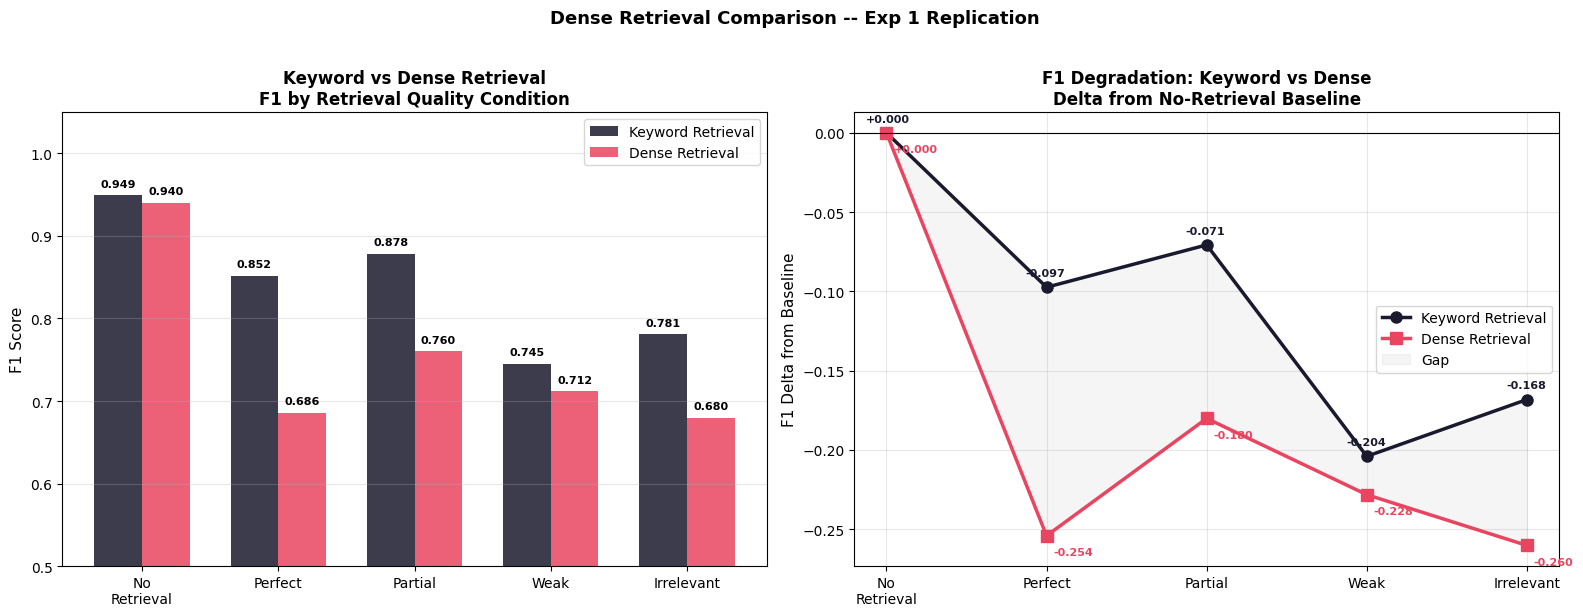

Saved to outputs/dense_vs_keyword.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Side by side comparison
conditions_display = ['No\nRetrieval', 'Perfect', 'Partial', 'Weak', 'Irrelevant']
keyword_f1 = [stats_all['exp1'][c]['f1_mean'] 
              for c in ['no_retrieval','perfect','partial','weak','irrelevant']]
dense_f1   = [dense_results[c]['f1'] 
              for c in ['no_retrieval','dense_perfect','dense_partial',
                        'dense_weak','dense_irrelevant']]

x     = np.arange(len(conditions_display))
width = 0.35

bars1 = axes[0].bar(x - width/2, keyword_f1, width,
                    label='Keyword Retrieval', color='#1a1a2e', alpha=0.85)
bars2 = axes[0].bar(x + width/2, dense_f1, width,
                    label='Dense Retrieval', color='#e94560', alpha=0.85)

for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(conditions_display)
axes[0].set_ylabel('F1 Score', fontsize=11)
axes[0].set_title('Keyword vs Dense Retrieval\nF1 by Retrieval Quality Condition',
                  fontsize=12, fontweight='bold')
axes[0].set_ylim(0.5, 1.05)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Delta from baseline
keyword_deltas = [f - keyword_f1[0] for f in keyword_f1]
dense_deltas   = [f - dense_f1[0]   for f in dense_f1]

axes[1].plot(conditions_display, keyword_deltas, color='#1a1a2e',
             linewidth=2.5, marker='o', markersize=8,
             label='Keyword Retrieval')
axes[1].plot(conditions_display, dense_deltas, color='#e94560',
             linewidth=2.5, marker='s', markersize=8,
             label='Dense Retrieval')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].fill_between(conditions_display, keyword_deltas, dense_deltas,
                     alpha=0.08, color='grey', label='Gap')

for i, (kd, dd) in enumerate(zip(keyword_deltas, dense_deltas)):
    axes[1].annotate(f'{kd:+.3f}', (i, kd),
                     textcoords="offset points", xytext=(-15, 8),
                     fontsize=8, color='#1a1a2e', fontweight='bold')
    axes[1].annotate(f'{dd:+.3f}', (i, dd),
                     textcoords="offset points", xytext=(5, -14),
                     fontsize=8, color='#e94560', fontweight='bold')

axes[1].set_ylabel('F1 Delta from Baseline', fontsize=11)
axes[1].set_title('F1 Degradation: Keyword vs Dense\nDelta from No-Retrieval Baseline',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle('Dense Retrieval Comparison -- Exp 1 Replication',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/dense_vs_keyword.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/dense_vs_keyword.png")